In [1]:
import os
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)
from tensorflow.keras.utils import to_categorical
import timm

sns.set(style="whitegrid")

In [2]:
BASE_PATH = Path(r"E:\Thesis")

HAM_PATH = BASE_PATH / "HAM10000"
PAD_PATH = BASE_PATH / "PAD-UFES-20"

HAM_IMAGE_DIR = HAM_PATH / "images"
PAD_IMAGE_DIR = PAD_PATH / "images"

MODEL_DIR = BASE_PATH / "outputs" / "efficientnetb3_baseline"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

OUT_DIR = MODEL_DIR

BEST_MODEL_PATH = OUT_DIR / "best_effb3.pth"
LAST_MODEL_PATH = OUT_DIR / "last_effb3.pth"
HISTORY_CSV = OUT_DIR / "history.csv"
HISTORY_JSON = OUT_DIR / "history.json"
HISTORY_PKL = OUT_DIR / "history.pkl"

TRAIN_SPLIT_CSV = OUT_DIR / "train_split.csv"
VAL_SPLIT_CSV = OUT_DIR / "val_split.csv"
PAD_TEST_SPLIT_CSV = OUT_DIR / "pad_test_split.csv"

IMG_SIZE = (300, 300)   # EfficientNetB3-এর জন্য standard-friendly
BATCH_SIZE = 4
EPOCHS = 20
CLASS_NAMES = ["ACK", "BCC", "MEL", "NEV"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Output dir:", OUT_DIR)
print("HAM exists:", HAM_PATH.exists())
print("PAD exists:", PAD_PATH.exists())

Device: cuda
Output dir: E:\Thesis\outputs\efficientnetb3_baseline
HAM exists: True
PAD exists: True


In [3]:
ham = pd.read_csv(HAM_PATH / "HAM10000_metadata.csv")
pad = pd.read_csv(PAD_PATH / "metadata.csv")

HAM_CLASSES = ["akiec", "bcc", "mel", "nv"]
PAD_CLASSES = ["ACK", "BCC", "MEL", "NEV"]

ham_4 = ham[ham["dx"].isin(HAM_CLASSES)].copy()
ham_4["label"] = ham_4["dx"].map({
    "akiec": "ACK",
    "bcc": "BCC",
    "mel": "MEL",
    "nv": "NEV"
})
ham_4["image_path"] = ham_4["image_id"].apply(lambda x: str(HAM_IMAGE_DIR / f"{x}.jpg"))
ham_4 = ham_4[ham_4["image_path"].apply(os.path.exists)].copy()

pad_4 = pad[pad["diagnostic"].isin(PAD_CLASSES)].copy()
pad_4["label"] = pad_4["diagnostic"]
pad_4["image_path"] = pad_4["img_id"].apply(lambda x: str(PAD_IMAGE_DIR / x))
pad_4 = pad_4[pad_4["image_path"].apply(os.path.exists)].copy()

print("HAM samples:", len(ham_4))
print(ham_4["label"].value_counts())
print("\nPAD samples:", len(pad_4))
print(pad_4["label"].value_counts())

HAM samples: 8659
label
NEV    6705
MEL    1113
BCC     514
ACK     327
Name: count, dtype: int64

PAD samples: 1871
label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [4]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(gss.split(ham_4, groups=ham_4["lesion_id"]))

train_df = ham_4.iloc[train_idx].copy()
val_df = ham_4.iloc[val_idx].copy()

print("Train samples:", len(train_df))
print("Val samples:", len(val_df))
print("PAD test samples:", len(pad_4))

print("\nTrain class counts:")
print(train_df["label"].value_counts())

print("\nVal class counts:")
print(val_df["label"].value_counts())

Train samples: 6932
Val samples: 1727
PAD test samples: 1871

Train class counts:
label
NEV    5357
MEL     911
BCC     407
ACK     257
Name: count, dtype: int64

Val class counts:
label
NEV    1348
MEL     202
BCC     107
ACK      70
Name: count, dtype: int64


In [5]:
train_df.to_csv(TRAIN_SPLIT_CSV, index=False)
val_df.to_csv(VAL_SPLIT_CSV, index=False)
pad_4.to_csv(PAD_TEST_SPLIT_CSV, index=False)

In [6]:
class SkinDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_to_idx = CLASS_TO_IDX

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_path"]
        label = row["label"]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        y = self.label_to_idx[label]
        return image, torch.tensor(y, dtype=torch.long)

In [7]:
# Baseline-clean: only resize + normalization
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_dataset = SkinDataset(train_df, transform=train_transform)
val_dataset = SkinDataset(val_df, transform=test_transform)
pad_dataset = SkinDataset(pad_4, transform=test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

pad_loader = DataLoader(
    pad_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("PAD batches:", len(pad_loader))

Train batches: 1733
Val batches: 432
PAD batches: 468


In [8]:
model = timm.create_model(
    "efficientnet_b3",
    pretrained=True,
    num_classes=len(CLASS_NAMES)
).to(device)

print(model)

model.safetensors: reconstructing file:   0%|          |  0.00B / 49.3MB            

model.safetensors: downloading bytes:           |  0.00B            

c:\Users\parth\miniconda3\envs\tf\lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\parth\.cache\huggingface\hub\models--timm--efficientnet_b3.ra2_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


EfficientNet(
  (conv_stem): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
        (bn1): BatchNormAct2d(
          40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(40, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (b

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

C:\Users\parth\AppData\Local\Temp\ipykernel_11480\3240158511.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


In [10]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_probs = []
    all_preds = []
    all_true = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        running_loss += loss.item() * labels.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_true.append(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    all_true = np.concatenate(all_true, axis=0)

    return running_loss / total, correct / total, all_probs, all_preds, all_true

In [11]:
best_val_acc = -1.0
best_epoch = -1
patience = 5
patience_counter = 0
history = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
    val_loss, val_acc, val_probs, val_preds, val_true = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]["lr"]

    epoch_log = {
        "epoch": epoch + 1,
        "train_loss": float(train_loss),
        "train_acc": float(train_acc),
        "val_loss": float(val_loss),
        "val_acc": float(val_acc),
        "lr": float(current_lr)
    }
    history.append(epoch_log)

    pd.DataFrame(history).to_csv(HISTORY_CSV, index=False)

    history_clean = {k: [float(x) for x in v] for k, v in pd.DataFrame(history).to_dict(orient="list").items()}
    with open(HISTORY_JSON, "w") as f:
        json.dump(history_clean, f, indent=2)

    with open(HISTORY_PKL, "wb") as f:
        pickle.dump(history, f)

    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "history": history
    }, LAST_MODEL_PATH)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        patience_counter = 0

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_acc": best_val_acc,
            "best_epoch": best_epoch,
            "history": history
        }, BEST_MODEL_PATH)

        print(f"Saved best model at epoch {epoch+1} with val_acc={val_acc:.4f}")
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"lr={current_lr:.2e}"
    )

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}.")
        break

print("Training finished.")
print("Best val accuracy:", best_val_acc)
print("Best epoch:", best_epoch)

C:\Users\parth\AppData\Local\Temp\ipykernel_11480\1103833298.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
C:\Users\parth\AppData\Local\Temp\ipykernel_11480\1103833298.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Saved best model at epoch 1 with val_acc=0.8413
Epoch 01/20 | train_loss=0.6424 train_acc=0.7809 | val_loss=0.4738 val_acc=0.8413 | lr=1.00e-03


C:\Users\parth\AppData\Local\Temp\ipykernel_11480\1103833298.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
C:\Users\parth\AppData\Local\Temp\ipykernel_11480\1103833298.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Saved best model at epoch 2 with val_acc=0.8506
Epoch 02/20 | train_loss=0.4759 train_acc=0.8136 | val_loss=0.3967 val_acc=0.8506 | lr=1.00e-03


C:\Users\parth\AppData\Local\Temp\ipykernel_11480\1103833298.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
C:\Users\parth\AppData\Local\Temp\ipykernel_11480\1103833298.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


...

Epoch 09/20 | train_loss=0.2512 train_acc=0.8982 | val_loss=0.4285 val_acc=0.8535 | lr=5.00e-04


C:\Users\parth\AppData\Local\Temp\ipykernel_11480\1103833298.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
C:\Users\parth\AppData\Local\Temp\ipykernel_11480\1103833298.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 10/20 | train_loss=0.1457 train_acc=0.9462 | val_loss=0.3649 val_acc=0.8691 | lr=5.00e-04


C:\Users\parth\AppData\Local\Temp\ipykernel_11480\1103833298.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
C:\Users\parth\AppData\Local\Temp\ipykernel_11480\1103833298.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 11/20 | train_loss=0.0932 train_acc=0.9644 | val_loss=0.4138 val_acc=0.8633 | lr=5.00e-04
Early stopping triggered at epoch 11.
Training finished.
Best val accuracy: 0.8743485813549507
Best epoch: 6


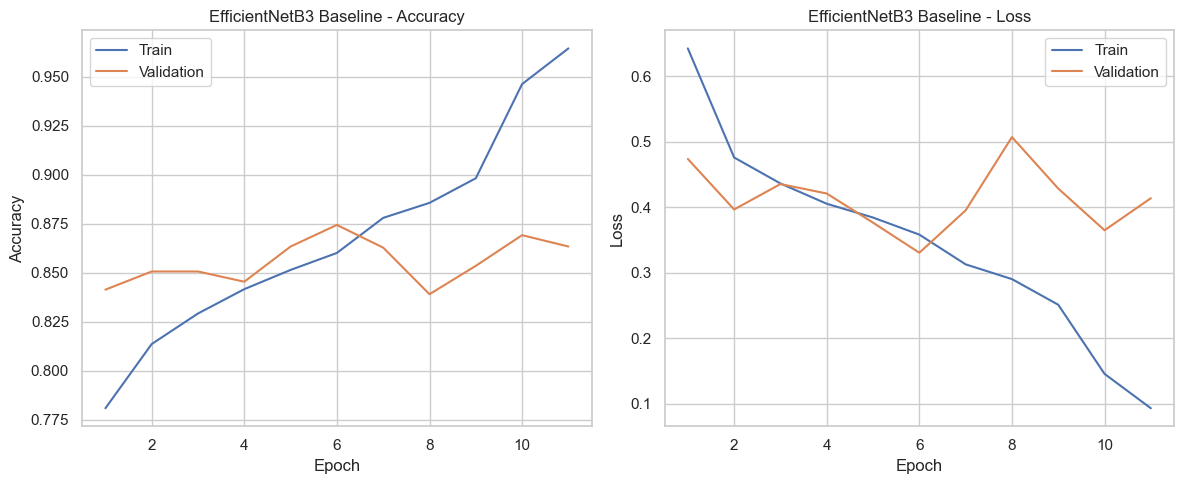

In [12]:
hist_df = pd.DataFrame(history)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_df["epoch"], hist_df["train_acc"], label="Train")
plt.plot(hist_df["epoch"], hist_df["val_acc"], label="Validation")
plt.title("EfficientNetB3 Baseline - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="Train")
plt.plot(hist_df["epoch"], hist_df["val_loss"], label="Validation")
plt.title("EfficientNetB3 Baseline - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
ckpt = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)
model.eval()

print("Best EfficientNetB3 checkpoint loaded.")
print("Best val acc from checkpoint:", ckpt["best_val_acc"])
print("Best epoch:", ckpt["best_epoch"])

Best EfficientNetB3 checkpoint loaded.
Best val acc from checkpoint: 0.8743485813549507
Best epoch: 6


In [14]:
pad_loss, pad_acc, pad_probs, pad_preds, pad_true = evaluate(model, pad_loader, criterion, device)

print("PAD Accuracy:", pad_acc)
print("PAD Loss:", pad_loss)

C:\Users\parth\AppData\Local\Temp\ipykernel_11480\1103833298.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


PAD Accuracy: 0.3554249064671299
PAD Loss: 2.647389513869008


In [15]:
acc = accuracy_score(pad_true, pad_preds)
prec = precision_score(pad_true, pad_preds, average="macro", zero_division=0)
rec = recall_score(pad_true, pad_preds, average="macro", zero_division=0)
f1 = f1_score(pad_true, pad_preds, average="macro", zero_division=0)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

print(
    classification_report(
        pad_true,
        pad_preds,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

true_onehot = to_categorical(pad_true, num_classes=len(CLASS_NAMES))
auc = roc_auc_score(true_onehot, pad_probs, multi_class="ovr", average="macro")
print("Macro AUC:", auc)

Accuracy : 0.3554249064671299
Precision: 0.3191189998737931
Recall   : 0.36547711668352034
F1 Score : 0.26104280336437813
              precision    recall  f1-score   support

         ACK       0.41      0.56      0.47       730
         BCC       0.56      0.07      0.13       845
         MEL       0.03      0.04      0.03        52
         NEV       0.27      0.79      0.41       244

    accuracy                           0.36      1871
   macro avg       0.32      0.37      0.26      1871
weighted avg       0.45      0.36      0.30      1871

Macro AUC: 0.6235140638024054


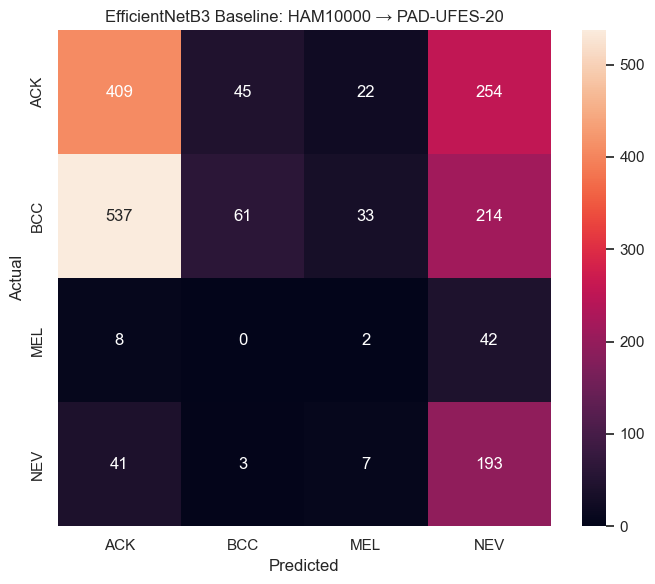

In [16]:
cm = confusion_matrix(pad_true, pad_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNetB3 Baseline: HAM10000 → PAD-UFES-20")
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
results = pd.DataFrame({
    "Experiment": ["EfficientNetB3 Baseline"],
    "PAD Accuracy": [acc],
    "Macro Precision": [prec],
    "Macro Recall": [rec],
    "Macro F1": [f1],
    "Macro AUC": [auc]
})

print(results)
results.to_csv(OUT_DIR / "final_results.csv", index=False)

run_info = {
    "model": "efficientnet_b3",
    "best_val_acc": float(best_val_acc),
    "best_epoch": int(best_epoch),
    "pad_accuracy": float(acc),
    "pad_precision": float(prec),
    "pad_recall": float(rec),
    "pad_f1": float(f1),
    "pad_auc": float(auc),
}

with open(OUT_DIR / "run_info.json", "w") as f:
    json.dump(run_info, f, indent=2)

with open(OUT_DIR / "run_info.txt", "w") as f:
    for k, v in run_info.items():
        f.write(f"{k}: {v}\n")

print("All outputs saved in:", OUT_DIR)

                Experiment  PAD Accuracy  Macro Precision  Macro Recall  \
0  EfficientNetB3 Baseline      0.355425         0.319119      0.365477   

   Macro F1  Macro AUC  
0  0.261043   0.623514  
All outputs saved in: E:\Thesis\outputs\efficientnetb3_baseline
